#   Vision Classification Pipeline — Computer Vision Project Tracker

##  ✅ Phase 1 — Setup & Data Pipeline

In [31]:
import pandas as pd
train = pd.read_csv('D:\\Coding\\vision-classification-pipeline\\src\\train.csv')
print(train.shape)
print(train.head())
#   each row = one image = 1 label + 784 pixel values

(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

Label: 0.0


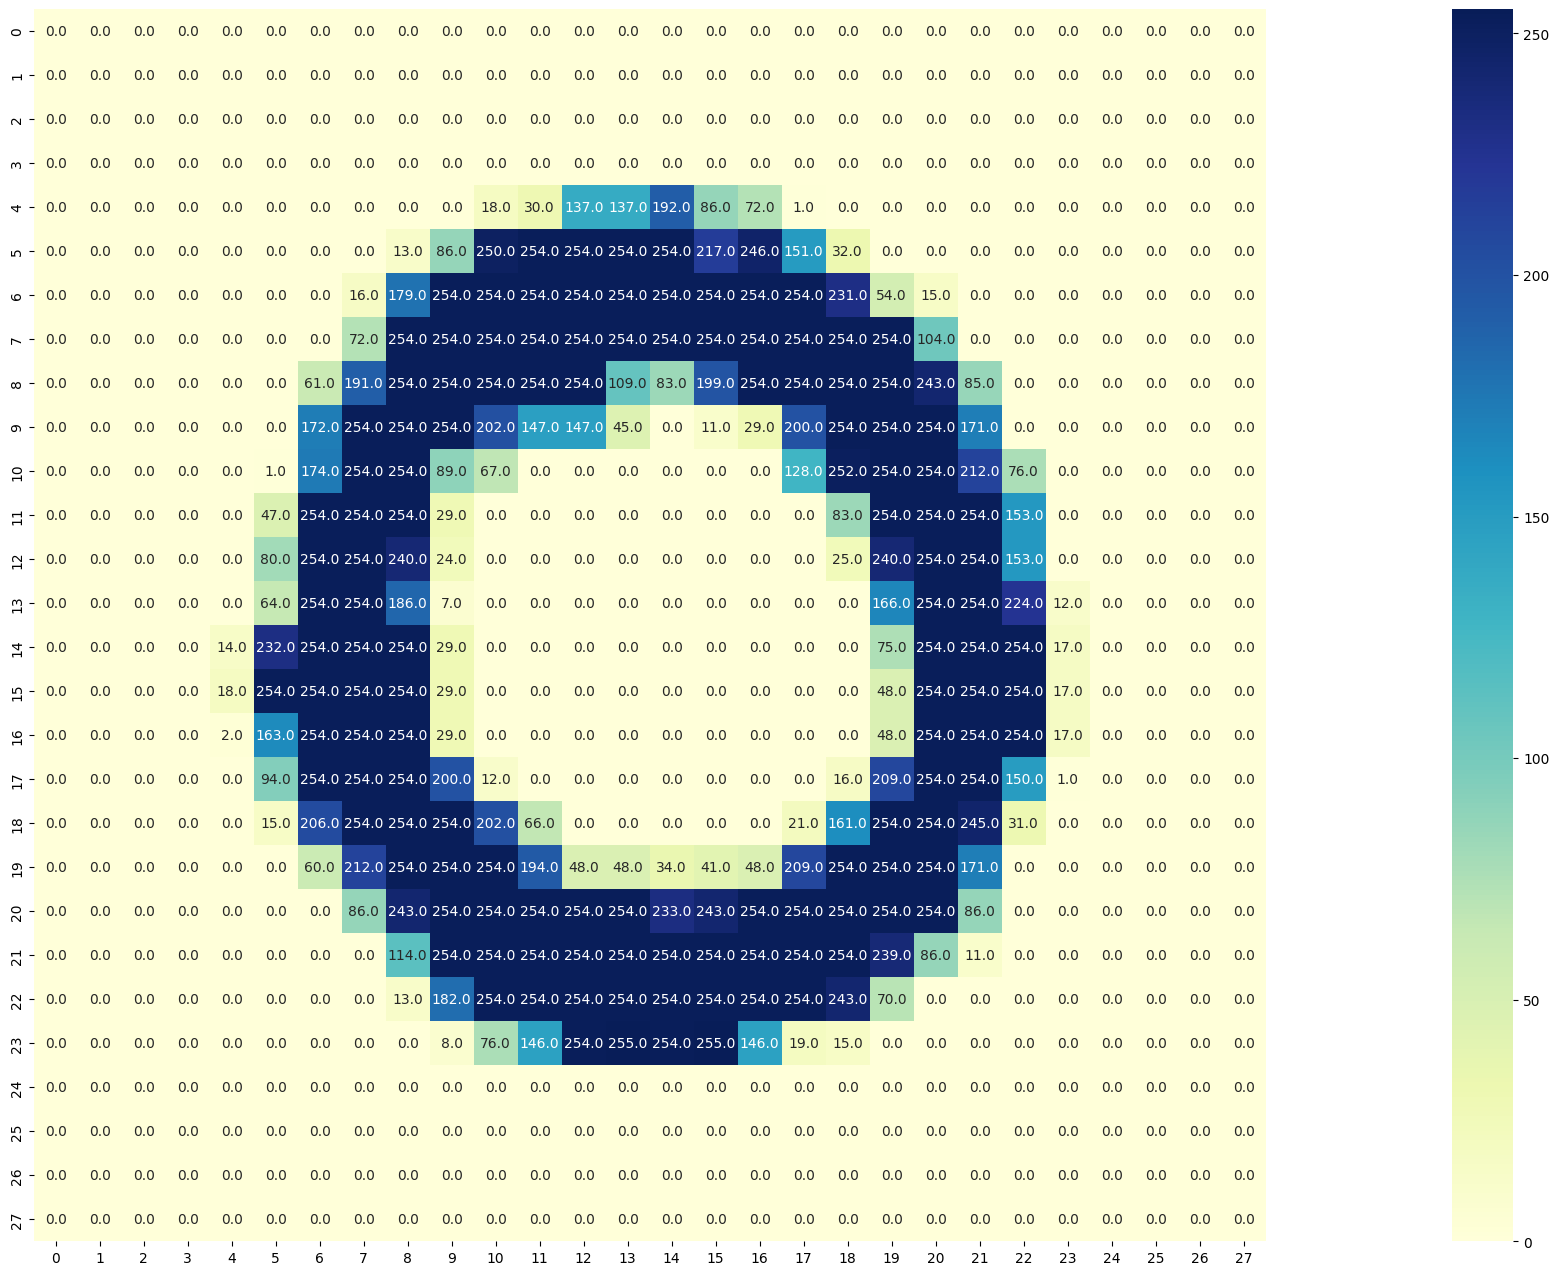

In [32]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# 1. Load the CSV file (Skip the header row if your CSV has one)
# Replace ',' with your actual delimiter if it is different (e.g., ';' or '\t')
data = np.loadtxt('D:\\Coding\\vision-classification-pipeline\\src\\train.csv', delimiter=',', skiprows=1)

# 2. Choose your instance index
i = 1 

# 3. Separate your features (X) and labels (Y) 
# ASSUMPTION: The first column is the label, and the remaining columns are pixels
label = data[i, 0]
flat_image = data[i, 1:]

# 4. Reshape the flat 1D array into a 2D image matrix
# Change (28, 28) to your image's actual height and width dimensions
image = flat_image.reshape(28, 28)

print(f"Label: {label}") 

# 5. Display the heatmap
f, ax = plt.subplots(figsize=(48, 16)) 
sns.heatmap(image, annot=True, fmt='.1f', square=True, cmap="YlGnBu") 
plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt


X = train.drop(columns=['label']).to_numpy(dtype=np.float32)
y = train['label'].to_numpy()

# Reshape all rows into 28x28 images
X_imgs = X.reshape(-1, 28, 28)

print("X shape:", X.shape)
print("X_imgs shape:", X_imgs.shape)
print("label sample:", y[:5])

X shape: (42000, 784)
X_imgs shape: (42000, 28, 28)
label sample: [1 0 1 4 0]


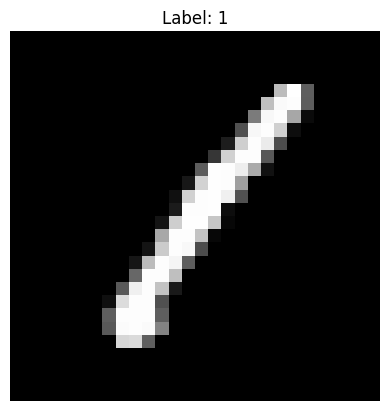

In [34]:
sample_idx = 0
plt.imshow(X_imgs[sample_idx], cmap='gray')
plt.title(f"Label: {y[sample_idx]}")
plt.axis('off')
plt.show()

In [35]:
"""Normalization"""

X = train.drop(columns=['label']).to_numpy(dtype=np.float32)
y = train['label'].to_numpy()

X_norm = X / 255.0
print("Normalized range:", X_norm.min(), X_norm.max())
print("X_norm shape:", X_norm.shape)

X_norm_reshaped = X_norm.reshape(-1, 28, 28, 1)
print("X_norm_reshaped shape:", X_norm_reshaped.shape)

Normalized range: 0.0 1.0
X_norm shape: (42000, 784)
X_norm_reshaped shape: (42000, 28, 28, 1)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_norm_reshaped, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (33600, 28, 28, 1)
X_val: (8400, 28, 28, 1)
y_train: (33600,)
y_val: (8400,)


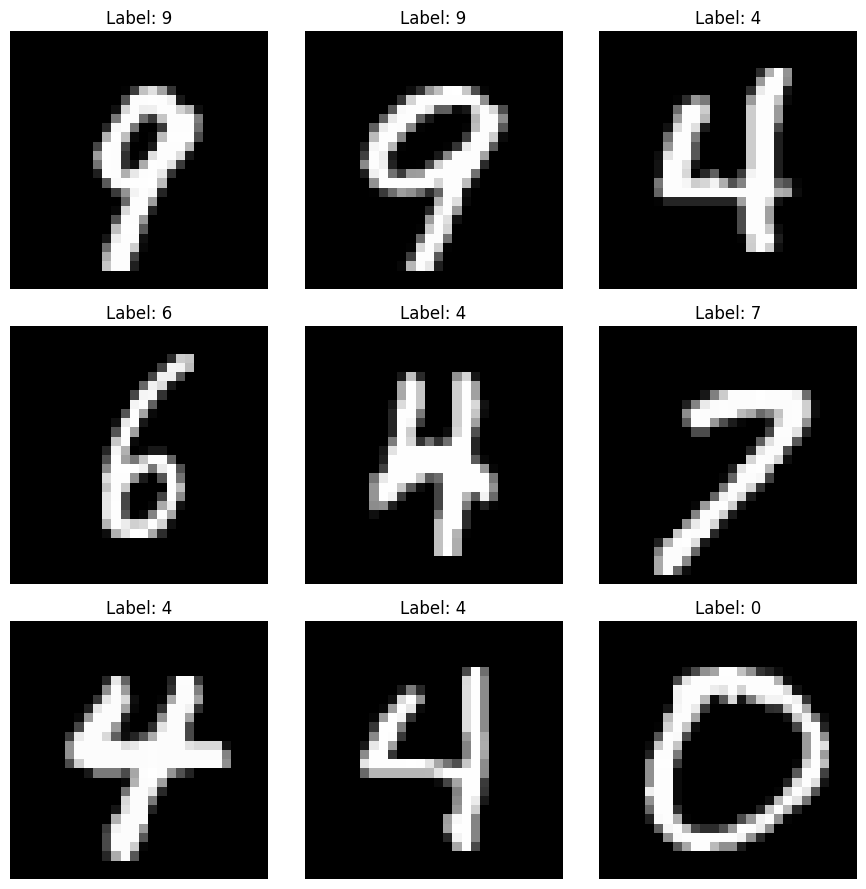

In [37]:
import matplotlib.pyplot as plt
import numpy as np

sample_indices = np.random.choice(len(X_train), 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.ravel()

for ax, idx in zip(axes, sample_indices):
    img = X_train[idx].squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

##  ✅ Phase 2 — Build CNN

In [38]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([keras.Input(shape=(28, 28, 1)),
                          layers.Conv2D(32, kernel_size= 3, activation= 'relu', padding = 'same'),
                          layers.MaxPooling2D(),
                          layers.Conv2D(filters = 64, kernel_size= 3, activation= 'relu', padding = 'same'),
                          layers.MaxPooling2D(),
                          layers.Flatten(),
                          layers.Dense(128, activation= 'relu'),
                          layers.Dropout(0.3),
                          layers.Dense(10, activation = 'softmax')
                          ])
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:
import os
import shutil

GRAPHVIZ_BIN = r"C:\Program Files\Graphviz\bin"
if os.path.isdir(GRAPHVIZ_BIN):
    os.environ["PATH"] = GRAPHVIZ_BIN + os.pathsep + os.environ.get("PATH", "")

print("dot:", shutil.which("dot"))

dot: C:\Program Files\Graphviz\bin\dot.EXE


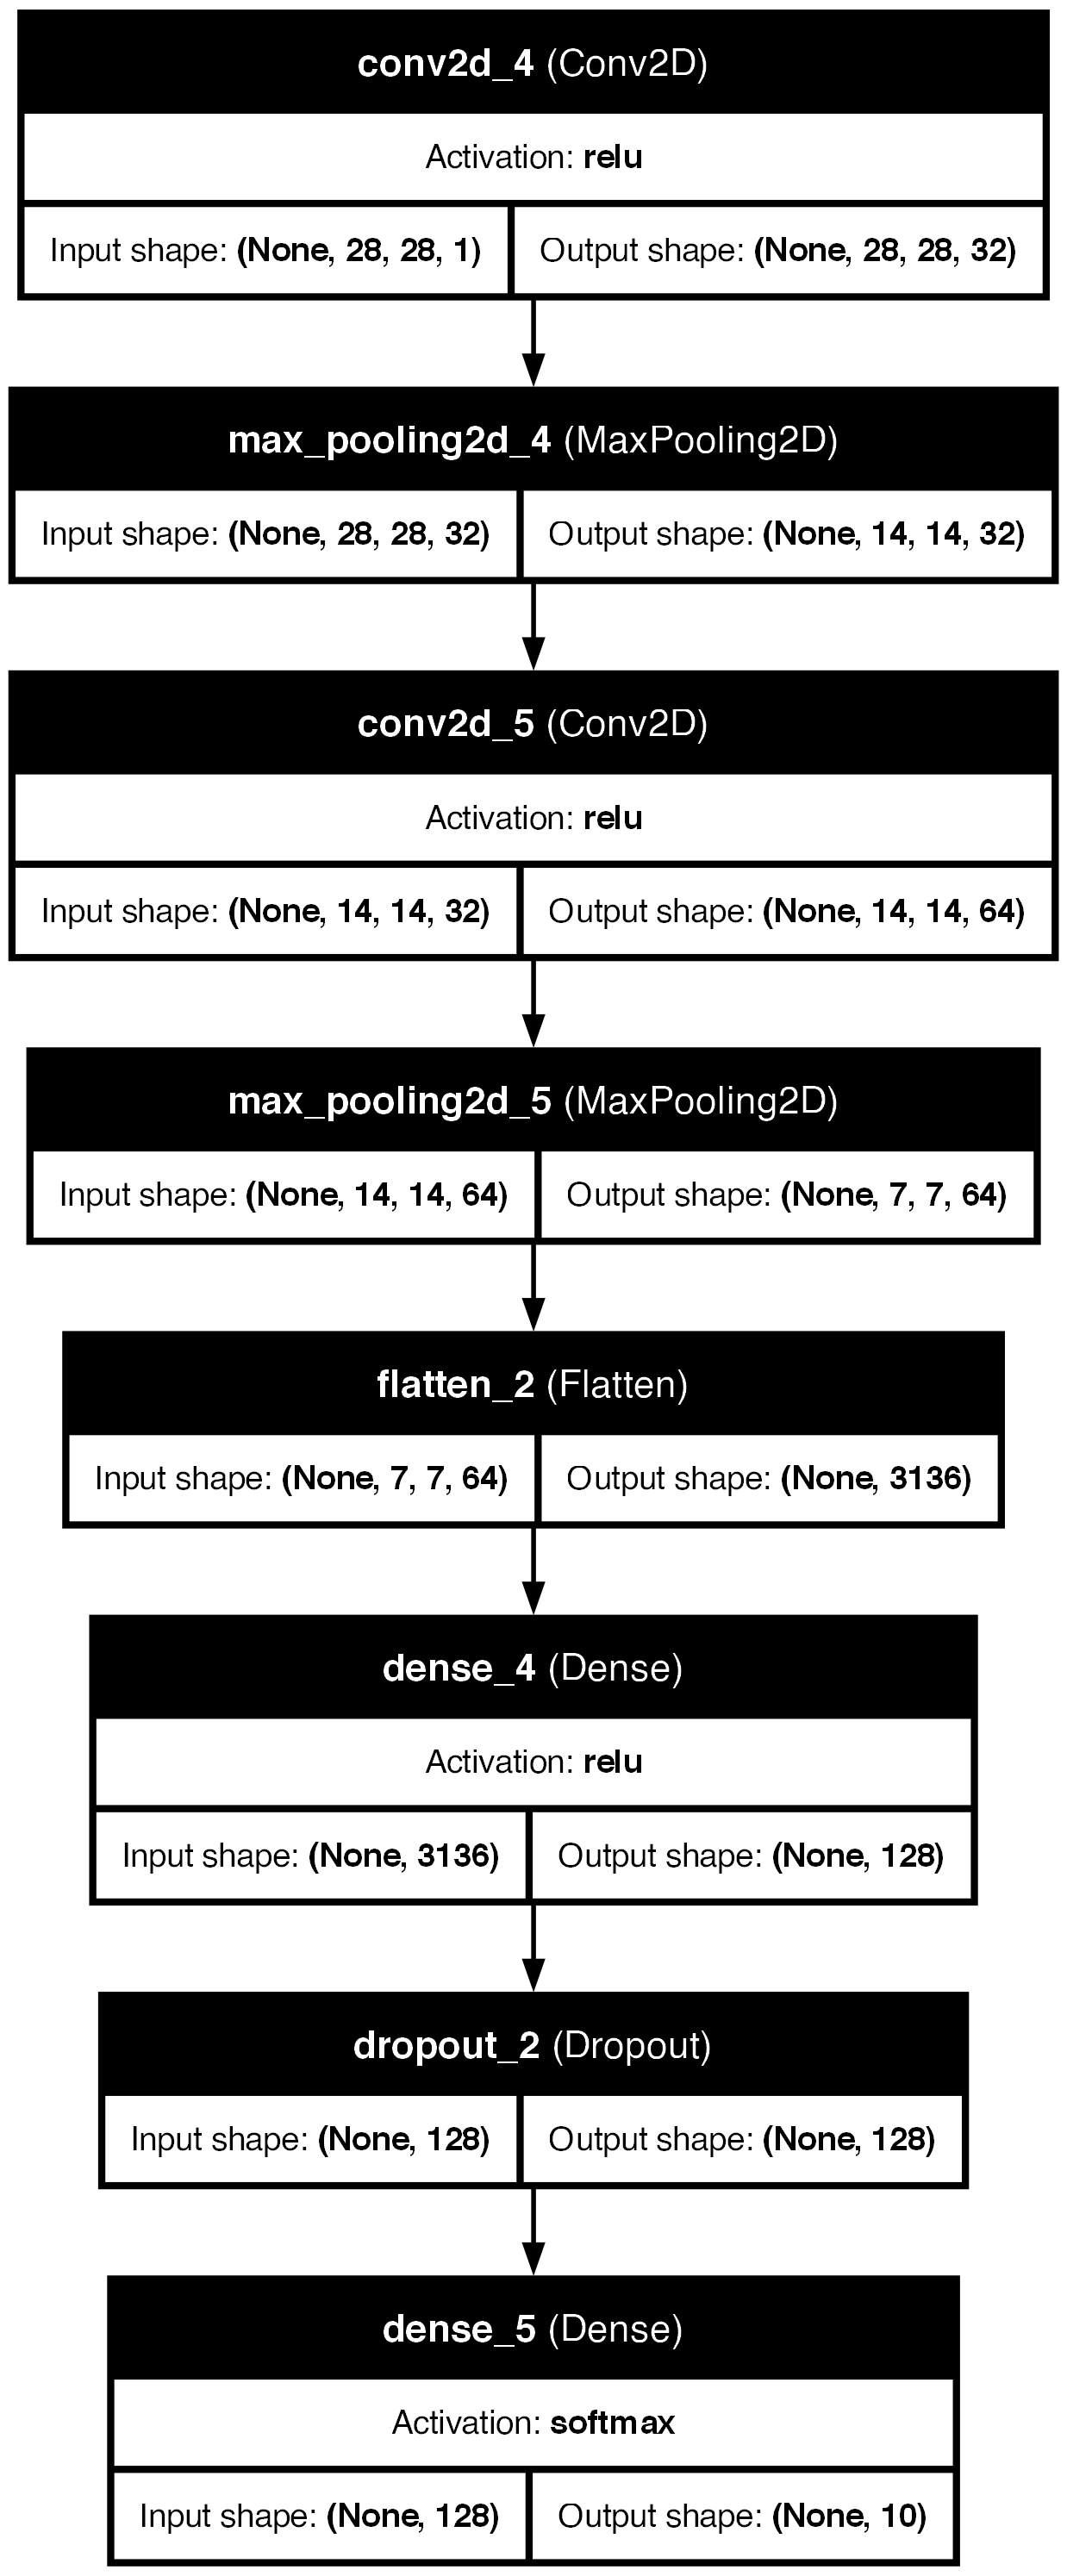

In [40]:
from tensorflow.keras.utils import plot_model

# This will generate the image and display it in your notebook
plot_model(model, 
            
           show_shapes=True, 
           show_layer_names=True,
           show_layer_activations=True)

In [41]:
model.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train, y_train, epochs = 10, batch_size= 32, validation_data= (X_val, y_val))


# Access the metrics dictionary
history_dict = history.history

# Print the keys (e.g., 'loss', 'accuracy', 'val_loss', 'val_accuracy')
print(history_dict.keys())
print(history_dict['accuracy'])


Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9346 - loss: 0.2161 - val_accuracy: 0.9768 - val_loss: 0.0730
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9781 - loss: 0.0704 - val_accuracy: 0.9807 - val_loss: 0.0626
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9840 - loss: 0.0505 - val_accuracy: 0.9865 - val_loss: 0.0429
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9875 - loss: 0.0381 - val_accuracy: 0.9863 - val_loss: 0.0483
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9876 - val_loss: 0.0426
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9906 - loss: 0.0285 - val_accuracy: 0.9870 - val_loss: 0.0441
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9929 - loss: 0.0218 - val_accuracy: 0.9876 - val_loss: 0.0449
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9934 - loss: 0.0187 - 

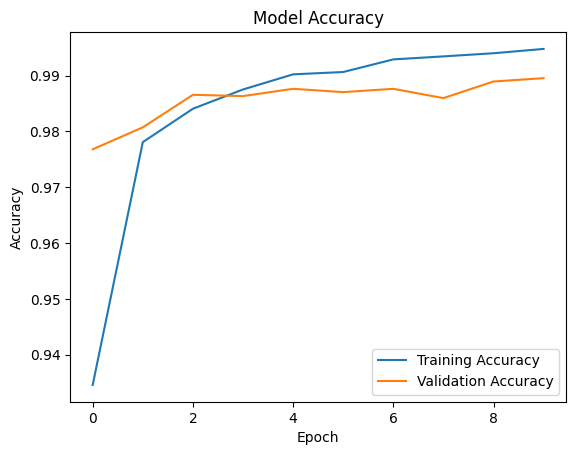

In [49]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

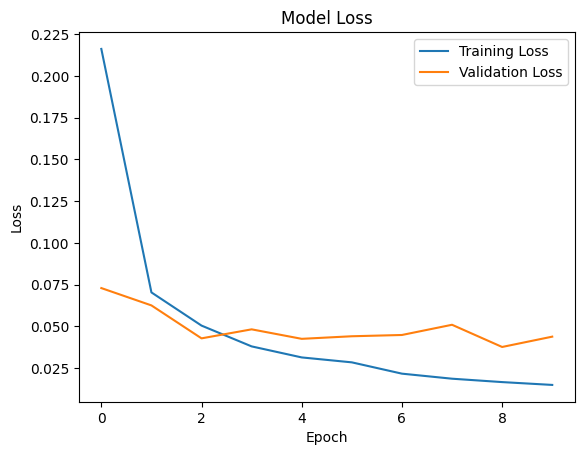

In [48]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()